### Agentic RAG
🤖 What is Agentic RAG?

Agentic RAG stands for Agentic Retrieval-Augmented Generation — an advanced version of RAG where instead of a static, one-shot LLM response,the system uses an agent that:

- reasons,
- plans,
- retrieves,
- uses tools,
- and even retries or reflects
to generate better, more grounded answers.

In [7]:
import os
import bs4
from typing import List, Annotated
from pydantic import BaseModel
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain.chat_models import init_chat_model
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_classic.schema import Document
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

In [ ]:
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["HF_TOKEN"] = os.getenv("HF_TOKEN")

llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CD0582E120>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CD0582EE40>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [3]:
# -----------------------------
# 1. Document Preprocessing
# -----------------------------
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2024-04-12-diffusion-video/"
]

loader = WebBaseLoader(
        web_paths=urls,
        header_template={"User-Agent": "MyRAGApp/1.0"}, 
        bs_kwargs={
            "parse_only": bs4.SoupStrainer(
            ["article", "main", "div"], 
            class_=["content", "post-text", "body", "post-content"] 
            )
        },
        bs_get_text_kwargs={
            "separator": " ", 
            "strip": True
        }
    )
    
docs = loader.load()

In [4]:
## Recursive character text ssplitter an vectorstore
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
split_docs = splitter.split_documents(docs)

embedding = HuggingFaceEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2")
vectorstore = FAISS.from_documents(split_docs, embedding)
retriever = vectorstore.as_retriever()

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5739.67it/s]


In [5]:
retriever.invoke("What are agents")

[Document(id='f60602c6-0847-4b06-8586-b35c7cab09bf', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT , GPT-Engineer and BabyAGI , serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver. Agent System Overview # In a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:'),
 Document(id='659313bf-f49b-4fd8-a809-193c950dcbed', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content="in order to optimize believability at the moment vs in time. Prompt template: {Intro of an agent X}. Here is X's plan today in broad strokes: 1) Relationships between agents and observations of one agent by another

In [6]:
# -----------------------------
# 2. Define RAG State
# -----------------------------
class RAGState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""

# -----------------------------
# 3. LangGraph Nodes
# -----------------------------
def retrieve_docs(state: RAGState) -> RAGState:
    docs = retriever.invoke(state.question)
    return RAGState(question=state.question, retrieved_docs=docs)


def generate_answer(state: RAGState) -> RAGState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"Answer the question based on the context.\n\nContext:\n{context}\n\nQuestion: {state.question}"
    response = llm.invoke(prompt)
    return RAGState(question=state.question, retrieved_docs=state.retrieved_docs, answer=response.content)

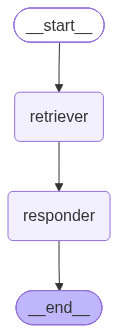

In [8]:
# -----------------------------
# 4. Build LangGraph
# -----------------------------

builder = StateGraph(RAGState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)

builder.add_edge(START, "retriever")
builder.add_edge("retriever", "responder")
builder.add_edge("responder", END)

graph = builder.compile()
graph

In [9]:
# -----------------------------
# 5. Run the Agentic RAG
# -----------------------------
if __name__ == "__main__":
    user_question = "What is the concept of agent loop in autonomous agents?"
    initial_state = RAGState(question=user_question)
    final_state = graph.invoke(initial_state)

    print("\n✅ Final Answer:\n", final_state['answer'])


✅ Final Answer:
 **Agent loop – the recurring “sense‑think‑act‑learn” cycle that drives an autonomous LLM‑powered agent**

In an autonomous agent the LLM acts as the “brain,” but it can only behave intelligently if it repeatedly goes through a short, well‑defined loop:

1. **Perceive / Observe** –  
   The agent reads the current state of its environment (e.g., a tree‑structured knowledge base, messages from other agents, sensor data, or the output of a code‑execution sandbox). This observation is turned into a structured prompt for the LLM.

2. **Think / Plan** –  
   Using the LLM (often with chain‑of‑thought or CoT prompting), the agent reasons about the observation, recalls relevant memories, decomposes the overall goal into sub‑tasks, and produces a concrete plan or next‑step instruction.  
   *Key sub‑components*: task decomposition, goal‑oriented planning, “belief” updating, and generation of an executable action description.

3. **Act / Execute** –  
   The plan is turned into

In [10]:
final_state

{'question': 'What is the concept of agent loop in autonomous agents?',
 'retrieved_docs': [Document(id='86838337-ea84-459c-b02d-4462bed68e79', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content='social behavior, such as information diffusion, relationship memory (e.g. two agents continuing the conversation topic) and coordination of social events (e.g. host a party and invite many others). Proof-of-Concept Examples # AutoGPT has drawn a lot of attention into the possibility of setting up autonomous agents with LLM as the main controller. It has quite a lot of reliability issues given the natural language interface, but nevertheless a cool proof-of-concept demo. A lot of code in AutoGPT'),
  Document(id='659313bf-f49b-4fd8-a809-193c950dcbed', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}, page_content="in order to optimize believability at the moment vs in time. Prompt template: {Intro of an agent X}. Here is X's plan